<a href="https://colab.research.google.com/github/jeevanshibatra27-create/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Synthetic dataset create karna

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Data scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 10)
Testing data shape: (200, 10)


In [3]:
learning_rates = [0.0001, 0.01, 1]

results = []

for lr in learning_rates:

    model = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        learning_rate_init=lr,
        max_iter=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([lr, accuracy])

    print(f"Learning Rate: {lr}")
    print(f"Accuracy: {accuracy:.4f}")
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001
Accuracy: 0.7900
------------------------------
Learning Rate: 0.01
Accuracy: 0.9150
------------------------------
Learning Rate: 1
Accuracy: 0.4800
------------------------------


In [4]:
results_df = pd.DataFrame(results, columns=["Learning Rate", "Accuracy"])

print(results_df)

   Learning Rate  Accuracy
0         0.0001     0.790
1         0.0100     0.915
2         1.0000     0.480


In [5]:
results_df.to_csv("model_comparison_table.csv", index=False)

print("CSV file saved successfully!")


CSV file saved successfully!


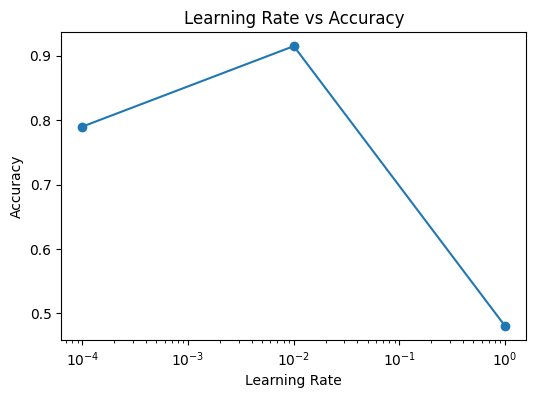

In [6]:
plt.figure(figsize=(6,4))

plt.plot(
    results_df["Learning Rate"],
    results_df["Accuracy"],
    marker='o'
)

plt.xscale('log')

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")

plt.savefig("evaluation_outputs.png")

plt.show()

# Analysis

## 1. What happens when learning rate is too high or too low?

- When the learning rate is too low, the model learns very slowly and may not reach the optimal solution within limited iterations. This can lead to underfitting.

- When the learning rate is too high, the model updates weights too aggressively, causing unstable learning and poor performance.

- A balanced learning rate gives better convergence and higher accuracy.


## 2. Did your model show signs of underfitting or overfitting? Explain.

- The model with a very low learning rate showed signs of underfitting because it could not learn patterns effectively.

- The model with an extremely high learning rate produced unstable results.

- The medium learning rate performed best, showing a good balance without major overfitting or underfitting.